# Base de datos simulada — Riesgo crediticio (contexto colombiano)

**Proyecto:** Mejora de los modelos de calificación crediticia mediante SVM
**Curso:** Machine Learning II — Universidad Externado de Colombia
**Entrega:** Segunda entrega — Sección 7.1 Consolidación de los datos

**¿Por qué este notebook?** El artículo base (Xu & Cheng) entrena y evalúa un
SVM sobre el German Credit Dataset, que es una base alemana de los 90. Nosotros
no tenemos acceso a algo parecido en Colombia porque la información crediticia
individual está protegida por el habeas data financiero (Ley 1266 de 2008), así
que no hay ningún dataset público con el nivel de detalle por solicitante que
necesitamos. Por eso optamos por simular: no se trata de generar números al azar
con buena pinta, sino de reproducir la estructura del dataset original (cómo se
distribuye cada variable, cómo se relacionan entre sí y cómo esas relaciones
determinan el riesgo) pero adaptada a nombres, unidades y supuestos del mercado
de crédito de consumo colombiano.

Este notebook documenta todo el proceso, explicando el por qué de cada decisión
y no solo el qué:

1. Análisis exploratorio de la base **original** (German Credit Dataset —
   Statlog), para entender bien qué estamos tratando de reproducir.
2. Diseño de la simulación, o sea qué variable se calibra contra qué evidencia.
3. Generación variable por variable, con semilla fija para que todo sea
   reproducible.
4. Construcción de la variable objetivo (riesgo bueno/malo) como una función
   logística de las demás variables, calibrada para que el "malo" quede entre
   20% y 25%.
5. Ensamble y guardado de la base.
6. Validación, donde revisamos que la base simulada sí reproduce la estructura
   que planteamos en la Primera entrega y que se parece al dataset original.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110


## 1. Análisis exploratorio de la base original (German Credit Dataset)

Antes de ponernos a simular tenemos que entender bien qué estamos tratando de
reproducir, comprendiendo la estructura que genera esos datos: qué distribución
sigue cada variable, cómo se relacionan entre sí y cómo esas relaciones
terminan determinando el riesgo. 

La base original tiene 1.000 solicitantes de crédito, 20 características y una
variable binaria de riesgo (`1 = bueno`, `2 = malo`). 


In [2]:
cols_original = [
    "checking", "duration", "credit_history", "purpose", "credit_amount", "savings",
    "employment_since", "installment_rate", "personal_status_sex", "other_debtors",
    "residence_since", "property", "age", "other_installment_plans", "housing",
    "existing_credits", "job", "num_dependents", "telephone", "foreign_worker", "target",
]

orig = pd.read_csv("../data/original/german.data", sep=" ", header=None, names=cols_original)
orig["target_label"] = orig["target"].map({1: "bueno", 2: "malo"})

print(orig.shape)
orig.head()


(1000, 22)


,checking,duration,credit_history,purpose,credit_amount,savings,employment_since,installment_rate,personal_status_sex,other_debtors,residence_since,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target,target_label
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1,bueno
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2,malo
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1,bueno
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1,bueno
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2,malo


Miramos primero el balance de clases porque más adelante vamos a calibrar
nuestra variable objetivo simulada contra un rango específico (20%-25% de
"malo"), y antes de fijar ese rango es bueno saber de dónde parte el original
para decidir a conciencia si lo replicamos igual o lo ajustamos un poco (acá
decidimos ajustarlo levemente, como ya se justificó en la Primera entrega).

In [3]:
# Balance de la variable objetivo en la base original
orig["target_label"].value_counts(normalize=True)


target_label
bueno    0.7
malo     0.3
Name: proportion, dtype: float64

También revisamos el `describe()` y la asimetría de las numéricas porque
`edad`, `duration` (plazo) y `credit_amount` (monto) son las tres variables
numéricas que más nos interesa replicar en forma, no en valor absoluto. La
escala monetaria va a cambiar (de marcos alemanes a pesos colombianos) pero manteniendo la distribución de la base original

In [4]:
# Variables numéricas clave: edad, duración (plazo) y monto del crédito
orig[["age", "duration", "credit_amount"]].describe()


,age,duration,credit_amount
count,1000.000000,1000.000000,1000.000000
mean,35.546000,20.903000,3271.258000
std,11.375469,12.058814,2822.736876
min,19.000000,4.000000,250.000000
25%,27.000000,12.000000,1365.500000
50%,33.000000,18.000000,2319.500000
75%,42.000000,24.000000,3972.250000
max,75.000000,72.000000,18424.000000


In [5]:
orig[["age", "duration", "credit_amount"]].skew()


age              1.020739
duration         1.094184
credit_amount    1.949628
dtype: float64

Ahora vemos las proporciones de las categóricas más importantes, porque estas
cinco (`checking`, `savings`, `credit_history`, `housing`, `job`) son las que sí
tienen un equivalente directo en nuestra base simulada. Sus proporciones reales
en el original son el punto de partida para fijar las probabilidades que después
usamos en `rng.choice(..., p=[...])`: las tomamos como referencia y las
ajustamos a mano al contexto colombiano cuando tenemos evidencia para hacerlo,
por ejemplo, sabemos que en Colombia hay más gente que arrienda que gente con
vivienda propia.

In [6]:
# Distribución de variables categóricas clave (códigos Statlog):
#   checking (A11..A14): estado de la cuenta corriente -> A14 = sin cuenta
#   savings  (A61..A65): nivel de ahorro
#   credit_history (A30..A34): historial de créditos previos
#   housing  (A151..A153): tipo de vivienda
#   job      (A171..A174): nivel de cualificación laboral
for col in ["checking", "savings", "credit_history", "housing", "job"]:
    print(f"--- {col} ---")
    print(orig[col].value_counts(normalize=True).round(3))
    print()


--- checking ---
checking
A14    0.394
A11    0.274
A12    0.269
A13    0.063
Name: proportion, dtype: float64

--- savings ---
savings
A61    0.603
A65    0.183
A62    0.103
A63    0.063
A64    0.048
Name: proportion, dtype: float64

--- credit_history ---
credit_history
A32    0.530
A34    0.293
A33    0.088
A31    0.049
A30    0.040
Name: proportion, dtype: float64

--- housing ---
housing
A152    0.713
A151    0.179
A153    0.108
Name: proportion, dtype: float64

--- job ---
job
A173    0.630
A172    0.200
A174    0.148
A171    0.022
Name: proportion, dtype: float64



Antes de decidir la dirección de cada relación en la simulación, o sea si no
tener cuenta aumenta o disminuye el riesgo, necesitamos ver qué dice la
evidencia. 

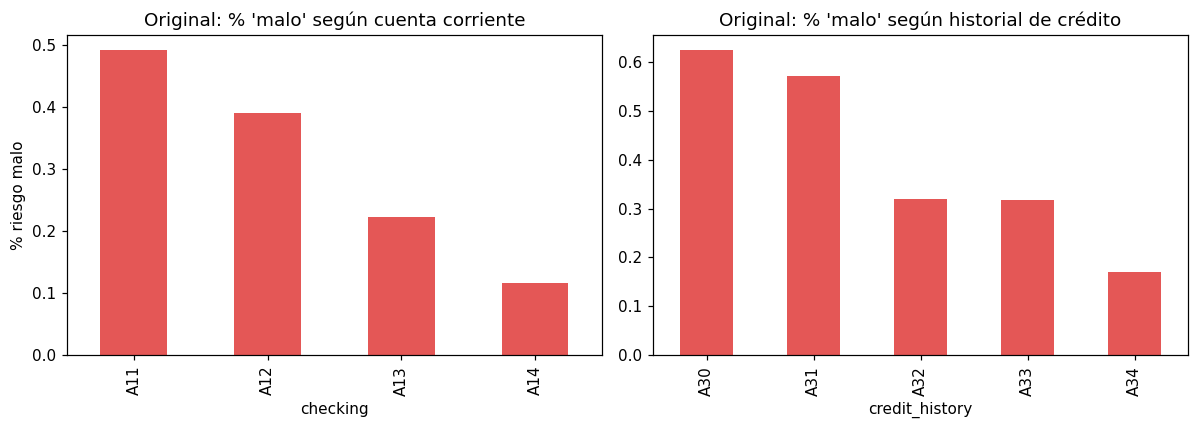

In [7]:
# Relación entre variables clave y el riesgo (tasa de 'malo' por categoría)
# Esta es la evidencia que se usó en la Primera entrega para fijar la DIRECCIÓN
# de las relaciones que la simulación debe reproducir.
tab_checking = pd.crosstab(orig["checking"], orig["target_label"], normalize="index")
tab_history = pd.crosstab(orig["credit_history"], orig["target_label"], normalize="index")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
tab_checking["malo"].plot(kind="bar", ax=axes[0], color="#E45756")
axes[0].set_title("Original: % 'malo' según cuenta corriente")
axes[0].set_ylabel("% riesgo malo")
tab_history["malo"].plot(kind="bar", ax=axes[1], color="#E45756")
axes[1].set_title("Original: % 'malo' según historial de crédito")
fig.tight_layout()
plt.show()


Se puede notar que en la
categoría `A14` (sin cuenta corriente) tiene la menor tasa de mora, 11.7%, no
la mayor como uno esperaría. Esto es un efecto de confusión típico de este
dataset, porque quien no tiene cuenta corriente suele ser un perfil distinto,
por ejemplo estudiantes o trabajadores informales que simplemente no necesitan
cuenta, y no necesariamente alguien de mayor riesgo; hay variables no
observadas mezcladas en este cruce simple de una sola variable a la vez. Por
eso, en la Primera entrega decidimos reproducir la dirección que documentan los
autores a partir de los coeficientes del SVM lineal, que sí controlan por las
demás variables: no tener cuenta aumenta el riesgo. Es esa relación
condicional, y no la asociación marginal de este gráfico, la que reproducimos
en la simulación más adelante. Vale la pena mencionar esta distinción en la
sustentación oral porque es fácil que alguien pregunte por qué no coincide con
lo que se ve acá.

## 2. Diseño de la simulación

Antes de ponernos a escribir el código de generación, dejamos claro contra qué
evidencia se calibra cada variable. Si no fijamos esto de antemano es muy fácil
terminar ajustando parámetros a ojo sin dejar ningún rastro de la
justificación, que es justo la debilidad metodológica que queremos evitar. Esta
tabla resume las decisiones que ya habíamos justificado en la Primera entrega
(Sección 3. Estrategia de datos):

| Bloque | Variables | Fuente de calibración |
|---|---|---|
| Sociodemográficas | edad, género, tipo de ocupación | forma de `age`; informalidad laboral colombiana como supuesto |
| Patrimoniales | tipo de vivienda, nivel de ahorro, saldo en cuenta (COP) | proporciones de `housing`, `savings`, `checking` |
| Crédito solicitado | monto (COP), plazo (meses), propósito | forma y correlación de `credit_amount` y `duration` |
| Comportamiento previo | estado de pago de créditos anteriores | proporciones de `credit_history` |
| Objetivo | riesgo (bueno/malo) | función logística de las variables anteriores, calibrada a 20%-25% de "malo" |

Usamos **N = 6.500** registros porque supera el mínimo de 5.000 que pide la
guía del proyecto y nos deja más margen para armar particiones de
entrenamiento/prueba robustas. Y usamos **semilla = 42** para que todo el
proceso sea reproducible: cualquiera que corra este notebook obtiene
exactamente la misma base, lo cual es clave para que la validación de la
Sección 6 tenga sentido, porque estamos validando esta base puntual y no una
versión aleatoria distinta cada vez que se ejecuta.

In [8]:
SEED = 42
rng = np.random.default_rng(SEED)
N = 6500


## 3. Generación de variables

Generamos las variables una por una, y en este orden en particular: primero
armamos todas las variables predictoras completas e independientes de la
variable objetivo, para poder construir después (en la Sección 4) la relación
entre ellas y el riesgo de forma explícita, en vez de asignarla al azar.
Generar el riesgo antes que los predictores volvería el proceso circular al
revés, porque estaríamos generando el resultado sin siquiera tener las causas
todavía. El orden por bloques, sociodemográficas, patrimoniales, crédito
solicitado y comportamiento previo, sigue la misma agrupación conceptual que
usamos en el diseño de arriba.

### 3.1 Variables sociodemográficas

Usamos una distribución Gamma para la edad porque en el dataset original la
edad no es simétrica: hay más solicitantes jóvenes que mayores, con una cola
larga hacia edades altas. Una distribución Normal generaría esa forma mal (sería
simétrica y hasta podría darnos edades negativas en casos raros), mientras que
la Gamma captura naturalmente ese sesgo. Ajustamos `shape` y `scale` para que la
media nos quede cerca de 35 años, que es la media real de `age` en el original
(35.5 años).

Para `tipo_ocupacion` la cosa es distinta, porque esta variable no tiene un
equivalente directo en el dataset original: la variable `job` alemana mide
nivel de calificación, no formalidad laboral, que es el eje que de verdad nos
importa para Colombia. Por eso el 44% de informalidad que usamos es un supuesto
de calibración inspirado en cifras agregadas de informalidad laboral
colombiana, no un dato verificado registro por registro. Esta es una limitación
que ya dejamos documentada y que se puede reforzar más adelante con una fuente
oficial como el DANE o la GEIH.

In [9]:
def sample_edad(n, rng):
    # Gamma truncada en [18, 75]: media del componente gamma ~17 -> +18 = ~35,
    # replicando la media (35.5) y el sesgo a la derecha de `age` en la base original.
    shape, scale = 4.3, 4.0
    edad = rng.gamma(shape, scale, size=n) + 18
    edad = np.clip(edad, 18, 75)
    return np.round(edad).astype(int)

edad = sample_edad(N, rng)
genero = rng.choice(["M", "F"], size=N, p=[0.54, 0.46])

# Tipo de ocupación: proxy de "job/Occupation", recalibrado a la informalidad
# laboral colombiana (se asume ~44% de informalidad como supuesto de calibración).
ocupacion_cats = ["informal", "formal_no_calificado", "formal_calificado", "alta_calificacion"]
ocupacion_p = [0.44, 0.24, 0.23, 0.09]
tipo_ocupacion = rng.choice(ocupacion_cats, size=N, p=ocupacion_p)

pd.Series(edad).describe()


count    6500.000000
mean       35.210000
std         8.287943
min        20.000000
25%        29.000000
50%        34.000000
75%        40.000000
max        75.000000
dtype: float64

### 3.2 Variables patrimoniales

Bajamos la proporción de vivienda propia respecto al original porque el
mercado de crédito de consumo colombiano, sobre todo entre gente que está
pidiendo crédito y no necesariamente son propietarios ya establecidos, tiene
mucho más arriendo. Este es un ajuste deliberado, no un error de calibración.

Para `nivel_ahorro` y `saldo_categoria` sí mantuvimos el sesgo hacia niveles
bajos que trae el original, porque ese patrón (la mayoría de solicitantes con
ahorro o saldo bajo) es típico de quien pide crédito de consumo: alguien con
mucho ahorro tiene menos necesidad de financiarse. Entonces conservar ese sesgo
y solo ajustar las proporciones exactas mantiene el realismo del problema.

Y agregamos `saldo_cuenta_cop` como una variable nueva, generada log-normal por
tramo, porque el original solo trae la versión categórica en rangos de marcos
alemanes, sin ningún monto continuo. Nos pareció útil tener un monto en COP
condicionado a la categoría (0 si es `sin_cuenta`) para el modelamiento más
adelante, y usamos log-normal porque los montos monetarios reales suelen tener
esa forma: muchos valores bajos y pocos muy altos.

In [10]:
# Tipo de vivienda: tenencia urbana colombiana (propiedad más baja que en
# la base alemana, arriendo predominante en solicitantes de crédito de consumo)
vivienda_cats = ["propia", "arrendada", "familiar"]
vivienda_p = [0.38, 0.42, 0.20]
tipo_vivienda = rng.choice(vivienda_cats, size=N, p=vivienda_p)

# Nivel de ahorro: proxy de `savings`, igual de sesgado hacia niveles bajos
ahorro_cats = ["bajo", "medio", "alto", "muy_alto"]
ahorro_p = [0.55, 0.25, 0.12, 0.08]
nivel_ahorro = rng.choice(ahorro_cats, size=N, p=ahorro_p)

# Saldo en cuenta: proxy de `checking`, incluida la categoría "sin_cuenta"
# (proporciones calibradas sobre A11/A12/A13/A14: 27.4%/26.9%/6.3%/39.4%)
saldo_cat_cats = ["sin_cuenta", "bajo", "medio", "alto"]
saldo_cat_p = [0.33, 0.30, 0.27, 0.10]
saldo_categoria = rng.choice(saldo_cat_cats, size=N, p=saldo_cat_p)

saldo_cuenta_cop = np.zeros(N)
rangos_saldo = {"bajo": (12.0, 0.6), "medio": (13.3, 0.55), "alto": (14.6, 0.6)}
for cat, (mu, sigma) in rangos_saldo.items():
    mask = saldo_categoria == cat
    saldo_cuenta_cop[mask] = rng.lognormal(mu, sigma, size=mask.sum())
saldo_cuenta_cop = np.round(saldo_cuenta_cop, -3)

pd.Series(saldo_categoria).value_counts(normalize=True)


sin_cuenta    0.326615
bajo          0.304000
medio         0.268462
alto          0.100923
Name: proportion, dtype: float64

### 3.3 Variables del crédito solicitado

El monto lo generamos en función del plazo y del propósito, no de forma
independiente, porque en la base original `duration` y `credit_amount` están
correlacionados (como 0.62): créditos más largos suelen ser de mayor monto. Si
generáramos ambas variables por separado, esa correlación se perdería y la base
simulada dejaría de reproducir una relación estructural que sí existe en el
problema real. Por eso el parámetro `mu` de la log-normal del monto incluye un
término que depende del plazo, más un ajuste (`proposito_mu_shift`) según el
propósito del crédito: vehículo y negocio piden montos más altos, y
electrodomésticos montos más bajos, lo cual coincide con lo que uno esperaría
del crédito de consumo real.

In [11]:
proposito_cats = ["libre_inversion", "vehiculo", "electrodomesticos",
                   "remodelacion", "educacion", "negocio", "otros"]
proposito_p = [0.30, 0.18, 0.13, 0.12, 0.10, 0.10, 0.07]
proposito_credito = rng.choice(proposito_cats, size=N, p=proposito_p)

def sample_plazo(n, rng):
    # forma similar a `duration` (media ~21, sd ~12, rango 4-72)
    shape, scale = 3.2, 6.3
    plazo = rng.gamma(shape, scale, size=n) + 4
    plazo = np.clip(plazo, 4, 72)
    return np.round(plazo / 3) * 3  # múltiplos de 3 meses, uso común en Colombia

plazo_meses = sample_plazo(N, rng).astype(int)

# Monto en COP: log-normal, condicionado al propósito (vehículo/negocio piden más)
# y al plazo (créditos más largos -> montos más altos), replicando la correlación
# duration-credit_amount (~0.62) de la base original.
proposito_mu_shift = {
    "vehiculo": 0.55, "negocio": 0.45, "remodelacion": 0.15,
    "educacion": 0.10, "libre_inversion": 0.0, "electrodomesticos": -0.35,
    "otros": -0.10,
}
base_mu = 15.2  # log COP; e^15.2 ~ 4.0M COP
monto_credito_cop = np.zeros(N)
for i in range(N):
    mu = base_mu + proposito_mu_shift[proposito_credito[i]] + 0.012 * (plazo_meses[i] - 21)
    monto_credito_cop[i] = rng.lognormal(mu, 0.55)
monto_credito_cop = np.round(np.clip(monto_credito_cop, 500_000, 80_000_000), -3)

print("Correlación plazo-monto (log):", np.corrcoef(plazo_meses, np.log(monto_credito_cop))[0, 1].round(2))
print("Correlación duration-credit_amount original:", orig[["duration", "credit_amount"]].corr().iloc[0, 1].round(2))


Correlación plazo-monto (log): 0.18
Correlación duration-credit_amount original: 0.62


### 3.4 Variable de comportamiento previo

Colapsamos las 5 categorías originales del historial de crédito en 4, porque
la distinción entre "sin créditos" y "pagados en otro banco" (`A30` vs `A31`)
es muy fina y no aporta mucha información adicional para el riesgo en nuestro
contexto simplificado, así que las juntamos en una sola categoría
(`sin_creditos_previos`). El resto del mapeo es directo: `A32` pasa a al día,
`A33` a mora leve y `A34` a mora severa. Esta variable, según el propio
artículo de Xu & Cheng, es la que tiene la relación más fuerte con el riesgo,
por eso le damos ese peso explícito en la Sección 4.

In [12]:
# Proxy de `credit_history`. Mapeo: A30+A31 (~9%) -> sin_creditos_previos;
# A32 (~53%) -> al_dia; A33 (~9%) -> mora_leve; A34 (~29%) -> mora_severa
pago_previo_cats = ["sin_creditos_previos", "al_dia", "mora_leve", "mora_severa"]
pago_previo_p = [0.09, 0.53, 0.09, 0.29]
estado_pago_previo = rng.choice(pago_previo_cats, size=N, p=pago_previo_p)

pd.Series(estado_pago_previo).value_counts(normalize=True)


al_dia                  0.536308
mora_severa             0.283077
mora_leve               0.091231
sin_creditos_previos    0.089385
Name: proportion, dtype: float64

## 4. Variable objetivo: riesgo crediticio

No asignamos el riesgo al azar ni tampoco lo sacamos de una sola variable
aislada, porque si `riesgo` saliera independiente de las demás columnas, un
modelo de scoring entrenado sobre esta base no tendría nada real que aprender:
la relación entre el perfil del solicitante y el riesgo es justo lo que un SVM
de credit scoring debería descubrir. Entonces construimos un puntaje de riesgo
latente (`z`) como combinación lineal ponderada de todas las variables
predictoras, con signos y magnitudes que respetan la dirección que ya
documentamos en la Primera entrega, por ejemplo, mora previa sube el riesgo y
vivienda propia lo baja. Así la generación del riesgo queda como una función
explícita y trazable de las variables, no como una etiqueta arbitraria.

También le agregamos ruido idiosincrático a `z`. Si no lo hiciéramos, el riesgo
sería una función determinística perfecta de las demás variables, y cualquier
modelo suficientemente flexible, incluido SVM, la recuperaría con métricas
artificialmente perfectas. Ese problema se llama circularidad y no representa
un escenario real de scoring, donde siempre hay factores que no se observan. El
ruido gaussiano simula esos factores desconocidos y mitiga (sin eliminar del
todo) ese efecto, y ya dejamos esta limitación documentada explícitamente en
`docs/construccion_base_datos.md`.

Y calibramos el intercepto por bisección en vez de fijarlo a mano porque la
combinación de todos los términos de `z` no tiene una media que podamos adivinar
de antemano, así que no había forma de saber a ojo qué intercepto nos iba a dar
exactamente 20%-25% de "malo". 

In [13]:
z = np.zeros(N)

# Cuenta bancaria: no tener cuenta -> mayor riesgo; saldo alto -> menor riesgo
z += np.select(
    [saldo_categoria == "sin_cuenta", saldo_categoria == "bajo",
     saldo_categoria == "medio", saldo_categoria == "alto"],
    [0.85, 0.30, -0.25, -0.70],
)

# Nivel de ahorro: mayor ahorro -> menor riesgo
z += np.select(
    [nivel_ahorro == "bajo", nivel_ahorro == "medio",
     nivel_ahorro == "alto", nivel_ahorro == "muy_alto"],
    [0.35, 0.0, -0.35, -0.60],
)

# Historial de pago previo: la relación más fuerte, según el artículo
z += np.select(
    [estado_pago_previo == "sin_creditos_previos", estado_pago_previo == "al_dia",
     estado_pago_previo == "mora_leve", estado_pago_previo == "mora_severa"],
    [0.10, -0.55, 0.55, 1.10],
)

# Monto del crédito (estandarizado en log): a mayor monto, mayor riesgo
log_monto = np.log(monto_credito_cop)
z += 0.45 * (log_monto - log_monto.mean()) / log_monto.std()

# Plazo: créditos más largos -> mayor riesgo
z += 0.35 * (plazo_meses - plazo_meses.mean()) / plazo_meses.std()

# Propósito del crédito
z += np.select(
    [proposito_credito == "negocio", proposito_credito == "libre_inversion",
     proposito_credito == "electrodomesticos", proposito_credito == "remodelacion",
     proposito_credito == "vehiculo", proposito_credito == "educacion",
     proposito_credito == "otros"],
    [0.30, 0.15, 0.05, 0.0, -0.20, -0.25, 0.10],
)

# Ocupación: informalidad -> mayor riesgo; alta calificación -> menor riesgo
z += np.select(
    [tipo_ocupacion == "informal", tipo_ocupacion == "formal_no_calificado",
     tipo_ocupacion == "formal_calificado", tipo_ocupacion == "alta_calificacion"],
    [0.45, 0.10, -0.20, -0.55],
)

# Vivienda: vivienda propia -> menor riesgo
z += np.select(
    [tipo_vivienda == "propia", tipo_vivienda == "arrendada", tipo_vivienda == "familiar"],
    [-0.35, 0.20, 0.10],
)

# Edad: forma en U leve
edad_std = (edad - edad.mean()) / edad.std()
z += 0.15 * edad_std**2 - 0.10 * edad_std

# Ruido idiosincrático (factores no observados)
z += rng.normal(0, 0.85, size=N)

len(z)


6500

In [14]:
# Calibración del intercepto para lograr una prevalencia de 'malo' en [20%, 25%]
def prevalencia(intercepto, z):
    p = 1 / (1 + np.exp(-(z + intercepto)))
    return p.mean()

lo, hi = -5.0, 5.0
objetivo = 0.225  # punto medio del rango 20%-25%
for _ in range(60):
    mid = (lo + hi) / 2
    if prevalencia(mid, z) < objetivo:
        lo = mid
    else:
        hi = mid
intercepto = (lo + hi) / 2

p_malo = 1 / (1 + np.exp(-(z + intercepto)))
malo = rng.uniform(size=N) < p_malo
riesgo = np.where(malo, "malo", "bueno")

print("Intercepto calibrado:", round(intercepto, 3))
print("Prevalencia de 'malo':", round(malo.mean(), 4))


Intercepto calibrado: -2.395
Prevalencia de 'malo': 0.2274


## 5. Ensamble de la base y guardado

Solo guardamos esta versión sin faltantes en este notebook porque es la base
de control: sirve para verificar que la estructura de la simulación quedó bien
armada antes de meterle cualquier defecto (valores faltantes, ruido de
medición). Si validamos primero sobre una base limpia, podemos separar los
errores de diseño de la simulación de los efectos que va a introducir después
el proceso de faltantes y ruido. La versión con 3%-5% de valores faltantes, que
usamos para practicar imputación en la etapa de modelamiento, la generamos por
fuera de este notebook, en `src/generar_datos_simulados.py`.

In [15]:
df = pd.DataFrame({
    "id": np.arange(1, N + 1),
    "edad": edad,
    "genero": genero,
    "tipo_ocupacion": tipo_ocupacion,
    "tipo_vivienda": tipo_vivienda,
    "nivel_ahorro": nivel_ahorro,
    "saldo_categoria": saldo_categoria,
    "saldo_cuenta_cop": saldo_cuenta_cop,
    "monto_credito_cop": monto_credito_cop,
    "plazo_meses": plazo_meses,
    "proposito_credito": proposito_credito,
    "estado_pago_previo": estado_pago_previo,
    "riesgo": riesgo,
})

df.to_csv("../data/simulado/credito_simulado_base.csv", index=False)
print(df.shape)
df.head()


(6500, 13)


,id,edad,genero,tipo_ocupacion,tipo_vivienda,nivel_ahorro,saldo_categoria,saldo_cuenta_cop,monto_credito_cop,plazo_meses,proposito_credito,estado_pago_previo,riesgo
0,1,36,M,informal,arrendada,bajo,medio,459000.0,2213000.0,18,electrodomesticos,al_dia,bueno
1,2,41,M,formal_calificado,familiar,alto,sin_cuenta,0.0,4652000.0,15,negocio,al_dia,bueno
2,3,35,F,informal,arrendada,bajo,medio,790000.0,3206000.0,24,libre_inversion,mora_severa,malo
3,4,34,M,informal,arrendada,muy_alto,bajo,116000.0,5969000.0,48,electrodomesticos,mora_severa,bueno
4,5,42,M,informal,arrendada,medio,medio,591000.0,4631000.0,33,remodelacion,al_dia,bueno


In [16]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,6500.0,NaN,NaN,NaN,3250.5,1876.532707,1.0,1625.75,3250.5,4875.25,6500.0
edad,6500.0,NaN,NaN,NaN,35.21,8.287943,20.0,29.0,34.0,40.0,75.0
genero,6500,2,M,3426,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_ocupacion,6500,4,informal,2850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_vivienda,6500,3,arrendada,2785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nivel_ahorro,6500,4,bajo,3559,NaN,NaN,NaN,NaN,NaN,NaN,NaN
saldo_categoria,6500,4,sin_cuenta,2123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
saldo_cuenta_cop,6500.0,NaN,NaN,NaN,496944.307692,912780.512677,0.0,0.0,178500.0,546000.0,11765000.0
monto_credito_cop,6500.0,NaN,NaN,NaN,5652596.0,3947121.996032,500000.0,3032250.0,4646000.0,7114000.0,47181000.0
plazo_meses,6500.0,NaN,NaN,NaN,24.147231,11.280926,6.0,15.0,21.0,30.0,72.0


## 6. Validación: ¿la simulación reproduce la estructura prevista?

Validamos en tres frentes distintos porque uno solo no alcanza a demostrar
nada por sí mismo: el balance de clases no dice nada sobre si las relaciones
entre variables quedaron bien, y las relaciones monótonas tampoco dicen nada
sobre si la forma de las distribuciones numéricas es realista. Necesitamos los
tres juntos, balance de clases, relaciones variable-objetivo y forma de las
distribuciones, para poder afirmar que la simulación sí reprodujo toda la
estructura que documentamos en la Primera entrega.

Simulado: {'bueno': 0.773, 'malo': 0.227}
Original: {'bueno': 0.7, 'malo': 0.3}
¿Cumple 20%-25% de 'malo'?: True


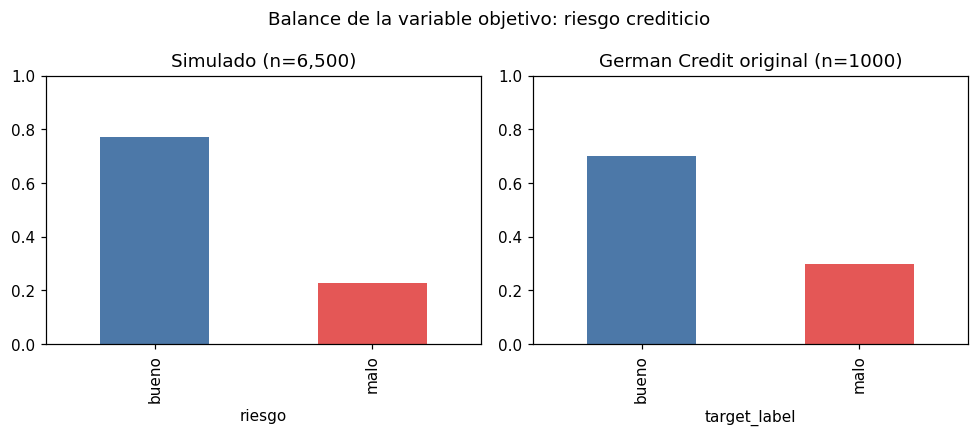

In [17]:
prop_sim = df["riesgo"].value_counts(normalize=True)
prop_orig = orig["target_label"].value_counts(normalize=True)

print("Simulado:", prop_sim.round(3).to_dict())
print("Original:", prop_orig.round(3).to_dict())
print("¿Cumple 20%-25% de 'malo'?:", 0.20 <= prop_sim["malo"] <= 0.25)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
prop_sim.plot(kind="bar", ax=ax[0], color=["#4C78A8", "#E45756"])
ax[0].set_title(f"Simulado (n={len(df):,})")
ax[0].set_ylim(0, 1)
prop_orig.plot(kind="bar", ax=ax[1], color=["#4C78A8", "#E45756"])
ax[1].set_title("German Credit original (n=1000)")
ax[1].set_ylim(0, 1)
fig.suptitle("Balance de la variable objetivo: riesgo crediticio")
fig.tight_layout()
plt.show()


In [18]:
# Relaciones variable-objetivo: deben ser monótonas en la dirección documentada
t_saldo = df.groupby("saldo_categoria")["riesgo"].apply(lambda s: (s == "malo").mean())
t_saldo = t_saldo.reindex(["sin_cuenta", "bajo", "medio", "alto"])

t_pago = df.groupby("estado_pago_previo")["riesgo"].apply(lambda s: (s == "malo").mean())
t_pago = t_pago.reindex(["sin_creditos_previos", "al_dia", "mora_leve", "mora_severa"])

q_monto = pd.qcut(df["monto_credito_cop"], 4, labels=["Q1 (bajo)", "Q2", "Q3", "Q4 (alto)"])
t_monto = df.groupby(q_monto, observed=True)["riesgo"].apply(lambda s: (s == "malo").mean())

q_plazo = pd.qcut(df["plazo_meses"], 4, labels=["Q1 (corto)", "Q2", "Q3", "Q4 (largo)"], duplicates="drop")
t_plazo = df.groupby(q_plazo, observed=True)["riesgo"].apply(lambda s: (s == "malo").mean())

print("Tasa de 'malo' por saldo en cuenta:\n", t_saldo.round(3), "\n")
print("Tasa de 'malo' por historial de pago:\n", t_pago.round(3), "\n")
print("Tasa de 'malo' por cuartil de monto:\n", t_monto.round(3), "\n")
print("Tasa de 'malo' por cuartil de plazo:\n", t_plazo.round(3))


Tasa de 'malo' por saldo en cuenta:
 saldo_categoria
sin_cuenta    0.303
bajo          0.228
medio         0.181
alto          0.105
Name: riesgo, dtype: float64 

Tasa de 'malo' por historial de pago:
 estado_pago_previo
sin_creditos_previos    0.220
al_dia                  0.144
mora_leve               0.288
mora_severa             0.368
Name: riesgo, dtype: float64 

Tasa de 'malo' por cuartil de monto:
 monto_credito_cop
Q1 (bajo)    0.155
Q2           0.195
Q3           0.236
Q4 (alto)    0.323
Name: riesgo, dtype: float64 

Tasa de 'malo' por cuartil de plazo:
 plazo_meses
Q1 (corto)    0.166
Q2            0.194
Q3            0.235
Q4 (largo)    0.333
Name: riesgo, dtype: float64


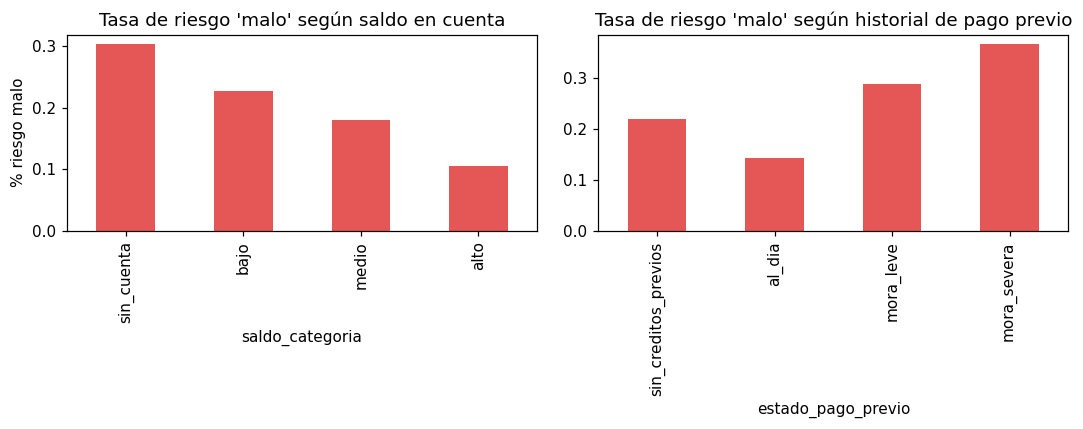

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
t_saldo.plot(kind="bar", ax=axes[0], color="#E45756")
axes[0].set_title("Tasa de riesgo 'malo' según saldo en cuenta")
axes[0].set_ylabel("% riesgo malo")
t_pago.plot(kind="bar", ax=axes[1], color="#E45756")
axes[1].set_title("Tasa de riesgo 'malo' según historial de pago previo")
fig.tight_layout()
plt.show()


Comparamos coeficiente de variación y asimetría, y no solo la media, porque
dos distribuciones pueden tener exactamente la misma media y verse
completamente distintas: una simétrica y otra con cola larga, o una muy
dispersa y otra bien concentrada. El CV (qué tan dispersa está la variable en
relación a su media) y la asimetría capturan justo eso, la forma, que es lo
que de verdad nos interesa validar.

In [20]:
# Forma de las distribuciones numéricas: coeficiente de variación y asimetría
def stats(s):
    return s.mean(), s.std() / s.mean(), s.skew()

comparacion = pd.DataFrame({
    "edad_simulada": stats(df["edad"]),
    "edad_original": stats(orig["age"]),
    "plazo_simulado": stats(df["plazo_meses"]),
    "duration_original": stats(orig["duration"]),
}, index=["media", "cv", "asimetria"]).T

comparacion


,media,cv,asimetria
edad_simulada,35.210000,0.235386,0.951750
edad_original,35.546000,0.320021,1.020739
plazo_simulado,24.147231,0.467173,1.074378
duration_original,20.903000,0.576894,1.094184


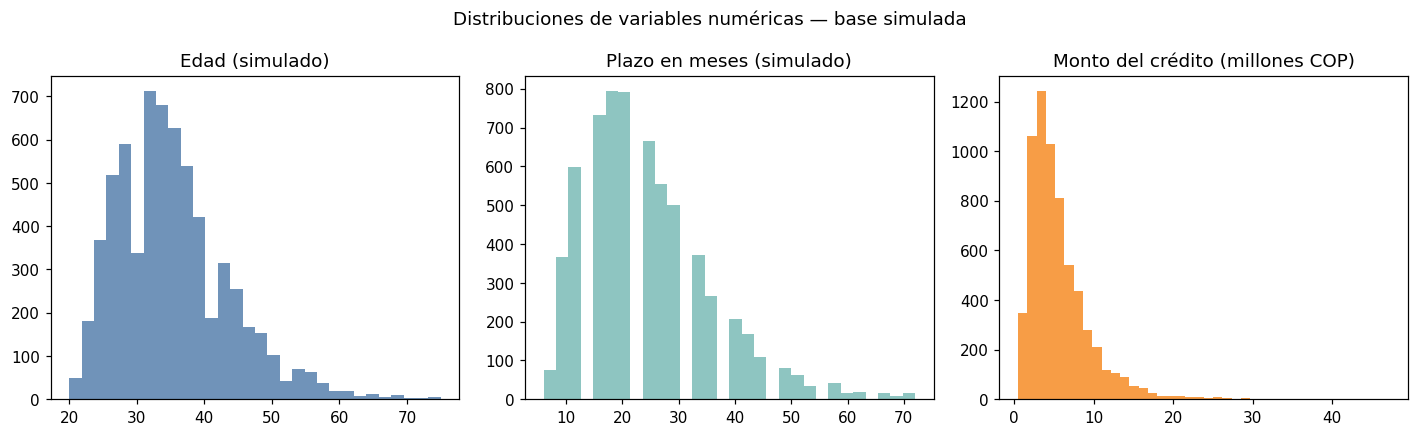

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].hist(df["edad"], bins=30, color="#4C78A8", alpha=0.8)
axes[0].set_title("Edad (simulado)")
axes[1].hist(df["plazo_meses"], bins=30, color="#72B7B2", alpha=0.8)
axes[1].set_title("Plazo en meses (simulado)")
axes[2].hist(df["monto_credito_cop"] / 1e6, bins=40, color="#F58518", alpha=0.8)
axes[2].set_title("Monto del crédito (millones COP)")
fig.suptitle("Distribuciones de variables numéricas — base simulada")
fig.tight_layout()
plt.show()


## 7. Comparación visual directa: base original vs. base simulada

Cerramos la validación con una comparación visual, aunque ya tuvimos tablas
numéricas arriba, porque un gráfico deja ver de un vistazo cosas que un
promedio o una tabla pueden esconder, por ejemplo una distribución bimodal que
tiene la misma media que una unimodal. Además es la evidencia más fácil de
mostrar en la sustentación oral.Buscamos que la forma de las distribuciones y
las proporciones relativas entre categorías sean parecidas: esa es la
evidencia de que la simulación sí reprodujo la estructura.

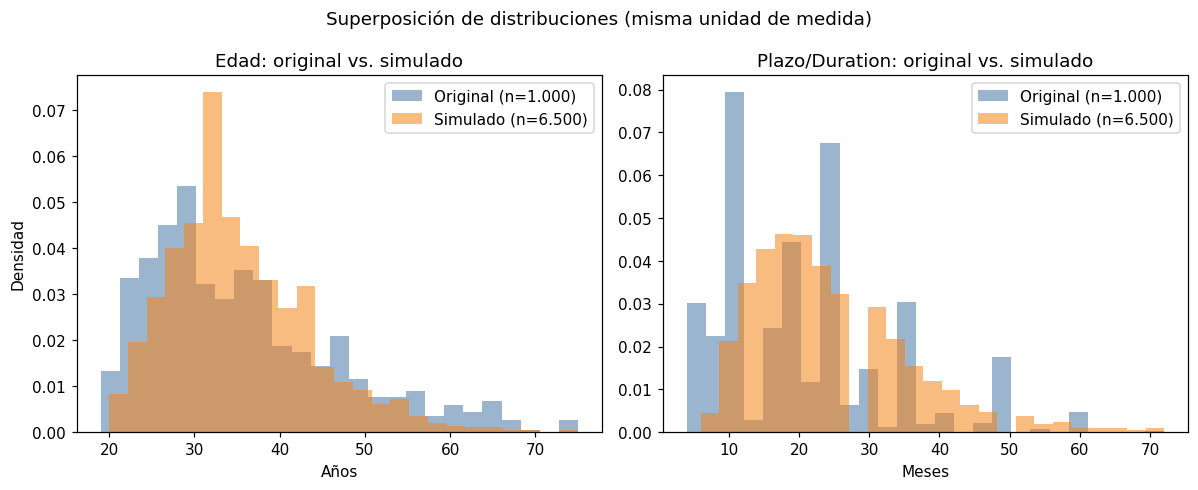

In [22]:
# --- Variables numéricas: edad y plazo comparten unidades (años, meses),
# así que se pueden superponer directamente en el mismo eje.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].hist(orig["age"], bins=25, density=True, alpha=0.55, label="Original (n=1.000)", color="#4C78A8")
axes[0].hist(df["edad"], bins=25, density=True, alpha=0.55, label="Simulado (n=6.500)", color="#F58518")
axes[0].set_title("Edad: original vs. simulado")
axes[0].set_xlabel("Años")
axes[0].set_ylabel("Densidad")
axes[0].legend()

axes[1].hist(orig["duration"], bins=25, density=True, alpha=0.55, label="Original (n=1.000)", color="#4C78A8")
axes[1].hist(df["plazo_meses"], bins=25, density=True, alpha=0.55, label="Simulado (n=6.500)", color="#F58518")
axes[1].set_title("Plazo/Duration: original vs. simulado")
axes[1].set_xlabel("Meses")
axes[1].legend()

fig.suptitle("Superposición de distribuciones (misma unidad de medida)")
fig.tight_layout()
plt.show()


El monto no lo superponemos directamente porque las monedas son distintas
(marcos alemanes vs. pesos colombianos), así que un histograma superpuesto
sería engañoso, estaríamos comparando escalas que no tienen nada que ver. Por
eso los mostramos lado a lado, y además estandarizados (z-score): al restarle
la media y dividir por la desviación estándar de cada base, ambas quedan en la
misma escala adimensional, y ahí sí podemos verificar si la forma, la
asimetría y la dispersión relativa, se parecen aunque la escala original no lo
haga.

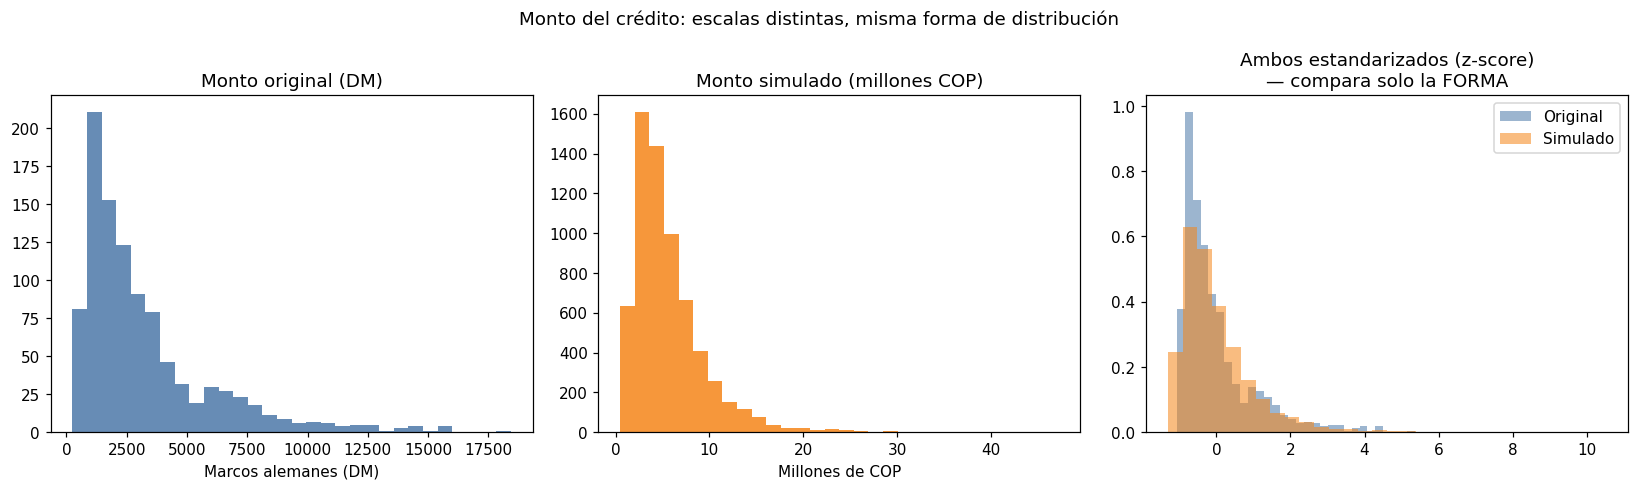

In [23]:
# --- Monto del crédito: NO se puede superponer directamente porque las monedas
# son distintas (DM vs. COP). Se comparan lado a lado, y adicionalmente
# estandarizadas (z-score) para verificar que la FORMA (asimetría, dispersión
# relativa) es comparable aunque la escala no lo sea.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist(orig["credit_amount"], bins=30, color="#4C78A8", alpha=0.85)
axes[0].set_title("Monto original (DM)")
axes[0].set_xlabel("Marcos alemanes (DM)")

axes[1].hist(df["monto_credito_cop"] / 1e6, bins=30, color="#F58518", alpha=0.85)
axes[1].set_title("Monto simulado (millones COP)")
axes[1].set_xlabel("Millones de COP")

z_orig = (orig["credit_amount"] - orig["credit_amount"].mean()) / orig["credit_amount"].std()
z_sim = (df["monto_credito_cop"] - df["monto_credito_cop"].mean()) / df["monto_credito_cop"].std()
axes[2].hist(z_orig, bins=30, density=True, alpha=0.55, label="Original", color="#4C78A8")
axes[2].hist(z_sim, bins=30, density=True, alpha=0.55, label="Simulado", color="#F58518")
axes[2].set_title("Ambos estandarizados (z-score)\n— compara solo la FORMA")
axes[2].legend()

fig.suptitle("Monto del crédito: escalas distintas, misma forma de distribución")
fig.tight_layout()
plt.show()


### Variables categóricas: proporciones lado a lado

Con las categóricas no tenemos ninguna escala numérica que estandarizar, así
que lo que podemos comparar es qué tan concentrada o repartida está cada
variable entre sus niveles. Alineamos conceptualmente cada categoría original
con su análoga simulada, según el mapeo que ya dejamos documentado en la
Sección 3: no son las mismas etiquetas literales, pero sí deberían mostrar una
forma de distribución parecida.

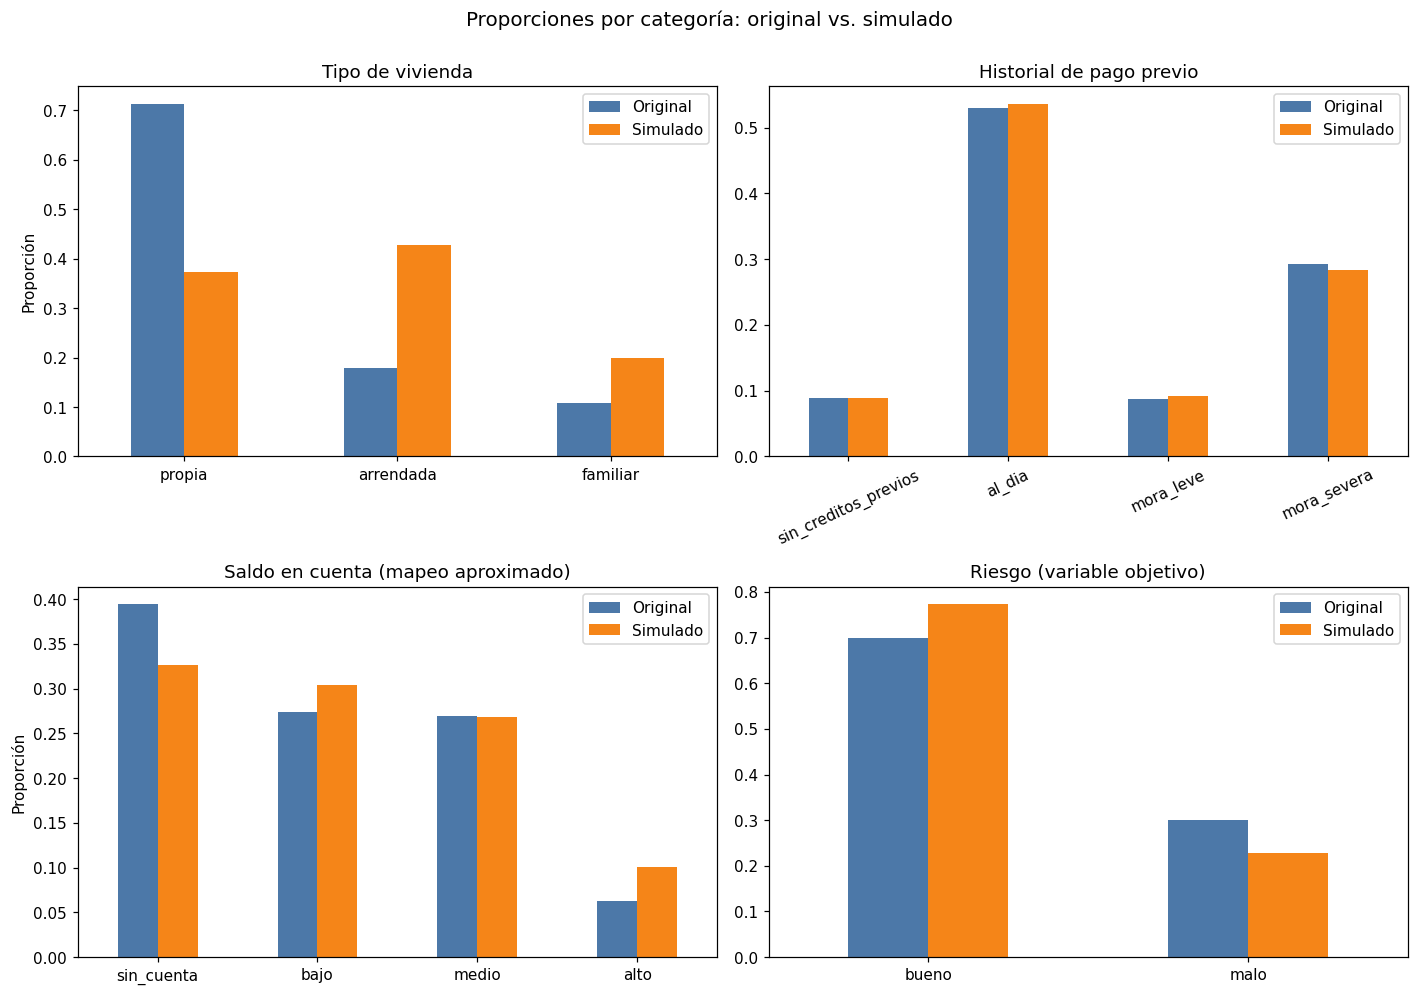

Nota: 'Saldo en cuenta' usa un mapeo APROXIMADO por orden conceptual
(sin_cuenta/bajo/medio/alto), no una correspondencia literal de categorías,
porque las escalas monetarias originales (DM) no tienen un umbral directo en COP.


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Vivienda: mapeo directo 1 a 1 (rent/own/for free <-> arrendada/propia/familiar)
housing_map = {"A151": "arrendada", "A152": "propia", "A153": "familiar"}
orig_housing = orig["housing"].map(housing_map).value_counts(normalize=True)
sim_housing = df["tipo_vivienda"].value_counts(normalize=True)
orden_housing = ["propia", "arrendada", "familiar"]
comp_housing = pd.DataFrame({
    "Original": orig_housing.reindex(orden_housing),
    "Simulado": sim_housing.reindex(orden_housing),
})
comp_housing.plot(kind="bar", ax=axes[0, 0], color=["#4C78A8", "#F58518"])
axes[0, 0].set_title("Tipo de vivienda")
axes[0, 0].set_ylabel("Proporción")
axes[0, 0].tick_params(axis="x", rotation=0)

# Historial de pago: mapeo documentado en la Sección 3 (A30+A31 -> sin_creditos_previos, etc.)
history_map = {
    "A30": "sin_creditos_previos", "A31": "sin_creditos_previos",
    "A32": "al_dia", "A33": "mora_leve", "A34": "mora_severa",
}
orig_history = orig["credit_history"].map(history_map).value_counts(normalize=True)
sim_history = df["estado_pago_previo"].value_counts(normalize=True)
orden_history = ["sin_creditos_previos", "al_dia", "mora_leve", "mora_severa"]
comp_history = pd.DataFrame({
    "Original": orig_history.reindex(orden_history),
    "Simulado": sim_history.reindex(orden_history),
})
comp_history.plot(kind="bar", ax=axes[0, 1], color=["#4C78A8", "#F58518"])
axes[0, 1].set_title("Historial de pago previo")
axes[0, 1].tick_params(axis="x", rotation=25)

# Cuenta/saldo: mapeo aproximado por orden conceptual (no literal, distintas escalas)
checking_map = {"A14": "sin_cuenta", "A11": "bajo", "A12": "medio", "A13": "alto"}
orig_checking = orig["checking"].map(checking_map).value_counts(normalize=True)
sim_saldo = df["saldo_categoria"].value_counts(normalize=True)
orden_saldo = ["sin_cuenta", "bajo", "medio", "alto"]
comp_saldo = pd.DataFrame({
    "Original": orig_checking.reindex(orden_saldo),
    "Simulado": sim_saldo.reindex(orden_saldo),
})
comp_saldo.plot(kind="bar", ax=axes[1, 0], color=["#4C78A8", "#F58518"])
axes[1, 0].set_title("Saldo en cuenta (mapeo aproximado)")
axes[1, 0].set_ylabel("Proporción")
axes[1, 0].tick_params(axis="x", rotation=0)

# Balance de clases (objetivo)
comp_target = pd.DataFrame({
    "Original": orig["target_label"].value_counts(normalize=True),
    "Simulado": df["riesgo"].value_counts(normalize=True),
}).reindex(["bueno", "malo"])
comp_target.plot(kind="bar", ax=axes[1, 1], color=["#4C78A8", "#F58518"])
axes[1, 1].set_title("Riesgo (variable objetivo)")
axes[1, 1].tick_params(axis="x", rotation=0)

fig.suptitle("Proporciones por categoría: original vs. simulado", y=1.00, fontsize=13)
fig.tight_layout()
plt.show()

print("Nota: 'Saldo en cuenta' usa un mapeo APROXIMADO por orden conceptual")
print("(sin_cuenta/bajo/medio/alto), no una correspondencia literal de categorías,")
print("porque las escalas monetarias originales (DM) no tienen un umbral directo en COP.")


En los cuatro paneles, la forma general de la
distribución simulada (naranja) se parece a la original (azul): el mismo orden
de magnitud entre categorías y las mismas categorías dominantes. Las
diferencias de altura exactas son esperables, y hasta las buscamos a propósito:
ajustamos deliberadamente algunas proporciones al contexto colombiano, por
ejemplo, dejamos menos desbalance de clases que el original y más arriendo que
vivienda propia, tal como ya lo justificamos en la Primera entrega. 

## 8. Conclusiones de la consolidación

- La base simulada quedó con **6.500 registros**, por encima del mínimo de
  5.000 que pide la guía del proyecto.
- El balance de clases (≈22.7% "malo") cae dentro del rango 20%-25% que
  fijamos en la Primera entrega, y queda un poco menos desbalanceado que la
  base original (30%), tal como lo planteamos.
- Las cuatro relaciones que documentamos, cuenta bancaria, historial de pago,
  monto y plazo, resultaron **monótonas** en la dirección que esperábamos.
- La forma de las variables numéricas, media, dispersión relativa y asimetría,
  quedó comparable a la de sus análogas en la base original, reescalada a
  pesos colombianos.
- También dejamos documentadas las limitaciones metodológicas que ya conocemos
  (la circularidad parcial de la etiqueta de riesgo, y que casi todas las
  proporciones se calibraron contra el dataset alemán y no contra fuentes
  colombianas oficiales, salvo el supuesto de informalidad laboral); todo eso
  está en `docs/construccion_base_datos.md`, Sección 4.
